# XRLF

### Interactive plot?
##### If you want to be able to rotate the plot (in a Jupyter Notebook) run this cell. Requires ipympl to be installed.

In [ ]:
%matplotlib widget

### Import libraries

In [4]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.collections import PolyCollection
from matplotlib import animation
import numpy as np
import pandas as pd
from astropy import units as u
from astropy.cosmology import LambdaCDM
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)



plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 14

### Define functions

In [6]:
# Flux to luminosity conversions
def X_flux_to_luminosity(f, redshift, EFmin, EFmax, ELmin, ELmax, tau):
    """
    Function for the conversion of EFmin-EFmax keV observed flux into rest frame ELmin-ELmaxkeV Luminosity.
    :param f: The Observed Flux
    :param redshift: The redshift of the source of the flux
    :param EFmin: The minimum of the energy range of the observed flux
    :param EFmax: The maximum of the energy range of the observed flux
    :param ELmin: The minimum of the energy range of the restframe Luminosity
    :param ELmax: The maximum of the energy range of the restframe Luminosity
    :return: The ELmin-ELmaxkeV rest-frame luminosity
    """
    power = 2.0 - tau
    lumDist = cosmo.luminosity_distance(redshift)
    lumDist = lumDist.to_value(u.cm)
    factor = ((ELmax ** power - ELmin ** power)/(EFmax ** power - EFmin ** power)) / (1 + redshift)**power
    return (4 * np.pi * lumDist**2.0) * factor * f

def R_flux_to_luminosity(f, redshift, alpha, freq_flux, freq_lum):
    """
    Converts the observed flux at freq_flux into a rest frame W/m/Hz Luminosity at freq_lum
    :param f: The Observed Flux in milli Jansky
    :param redshift: The redshift of the source of the flux
    :param freq_flux: frequency flux observed at
    :param freq_lum: frequency to calculate luminosity at   
    :alpha: The spectral index
    :return: The rest frame W/m/Hz Luminosity
    """
    power = 1 + alpha
    f = f * 10**(-26) *10**(-3)
    lumDist = cosmo.luminosity_distance(redshift)
    lumDist = lumDist.to_value(u.m)
    factor = ((freq_lum/freq_flux)**alpha) / (1 + redshift)**power
    return (4 * np.pi * lumDist**2.0) * factor * f

# XLF models
def ueda_XLF(Lx, z):
    """
    The Luminosity Dependent Density Evolution (LDDE) model of AGN X-ray luminosity function, fitted to the redshift
    range z=0-5, as modeled by Ueda et.al. (2014).
    :param Lx: logged X-ray luminosity array (independent variables)
    :param z: redshift
    :return:
    """
    h70 = cosmo.H0 / (70 * u.km / u.Mpc / u.s)
    # Initialise the variables
    A = 2.91
    Lstar_0 = 43.97
    gamma1 = 0.96
    gamma2 = 2.71
    p = 4.78
    beta = 0.84
    La1 = 44.61
    zstar_c1 = 1.86
    alpha1 = 0.29

    p1 = p + beta * (Lx - 44.0)
    p2 = -1.5
    p3 = -6.2

    # calculate z_c1 and z_c2 values based on the luminosity conditions
    zc1 = np.where(Lx <= La1, zstar_c1 * ((10 ** Lx / 10 ** La1) ** alpha1), zstar_c1)
    zc2 = np.where(Lx <= 44.0, 3.0 * ((10 ** Lx / 10 ** 44) ** -0.1), 3.0)

    # calculate the evolving parameter values based on the luminosity and redshift conditions
    # The where function is of the form (condition, value if satisfied, value if not satisfied)
    e = np.where(z <= zc1, (1 + z) ** p1,
                    ((1 + zc1) ** p1) * (((1 + z) / (1 + zc1)) ** p2))  # apply the z<=z_c1 condition first
    # now apply the zc2 condition, leaving the values that don't satisfy this as those given by the zc1 condition
    e = np.where(z > zc2, ((1 + zc1) ** p1) * (((1 + zc2) / (1 + zc1)) ** p2) * (((1 + z) / (1 + zc2)) ** p3), e)
    # Calculate the XLF
    faintEnd = ((10 ** Lx) / (10 ** Lstar_0)) ** gamma1
    brightEnd = ((10 ** Lx) / (10 ** Lstar_0)) ** gamma2
    phi = ((A * 1e-6 * h70.value ** 3.0) / (faintEnd + brightEnd)) * e
    return phi


def Aird2015_XLF(logLx, z, band):
    """
    The FDPL model of AGN X-ray luminosity function, as modeled by Aird et.al. (2015).

    Parameters
    ----------
    Lx : logged X-ray luminosity array (independent variables)
    z : redshift
    band : 1=soft, 2=hard

    Returns
    -------
    Phi/dlogL

    """
    C = np.log10(1+z)
    Lx = 10**logLx
    
    if band==2:
        logK = -5.13 + 4.73*C - 7.1*(C**2)        
        logLstar = 43.53 + 1.23*C + 3.35*(C**2) - 4.08*(C**3)       
        logy1 = -0.17 - 0.51*C       
        y2 = 2.31
    elif band==1:
        logK = -5.47 + 4.88*C - 7.2*(C**2)
        logLstar = 43.81 - 0.27*C + 6.82*(C**2) - 6.94*(C**3)
        logy1 = -0.18 - 0.55*C
        y2 = 2.34
    K = 10**logK
    Lstar = 10**logLstar
    y1 = 10**logy1
    
    phi = K*((((Lx/Lstar)**y1) + ((Lx/Lstar)**y2))**(-1))
    return phi

# RLF model
def Novak2018_RLF(L1, L2, z1, z2):
    """
    The model of AGN Radio luminosity function, as modeled by Novak et.al. (2018).

    Parameters
    ----------
    L1 : logged Radio luminosity minimum value
    L2 : logged Radio luminosity maximum value
    z1 : minimum redshift
    z2 : maximum redshift


    Returns
    -------
    Phi/dlogL

    """
    logLr = np.arange(L1, L2, 0.1)#np.arange(min(mid_L)-0.5, max(mid_L)+0.5, 0.1)
    Lr = 10**logLr

    z = (z1+z2)/2 # choose the centre of the redshift bin

    a_SF = 2.95
    B_SF = -0.29
    a_AGN = 2.86
    B_AGN = -0.70

    phi_star1 = 3.55e-3
    L_star1 = 1.85e21
    a1 = 1.22
    sig = 0.63

    efacSF = ((1+z)**(a_SF+z*B_SF))
    LrSF = Lr/efacSF
    efacAGN = ((1+z)**(a_AGN+z*B_AGN))
    LrAGN = Lr/efacAGN

    phi_SF = phi_star1*((LrSF/L_star1)**(1-a1))*np.exp((-1/(2*(sig**2)))*((np.log10(1+(LrSF/L_star1)))**2))

    phi_star2 = (1/0.4)*(10**(-5.5))
    L_star2 = 10**24.59
    a2 = -1.27
    B = -0.49

    phi_AGN = phi_star2/(((L_star2/LrAGN)**a2)+((L_star2/LrAGN)**B)) 
    phi_mod = phi_SF + phi_AGN
    
    return logLr, phi_mod, phi_SF, phi_AGN  

def polygon_under_graph(x, y):
    """
    Construct the vertex list which defines the polygon filling the space under
    the (x, y) line graph. This assumes x is in ascending order.
    """
    return [*zip(x, y)]

### Choose the redshift bin
##### Choose redsfhit bin range between two consecutive numbers from: 0.01, 0.25, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 6.0

In [36]:
z1 = 0.5 # beginning of redshift range
z2 = 1.0 # end of redshift range

### Plot the XRLF

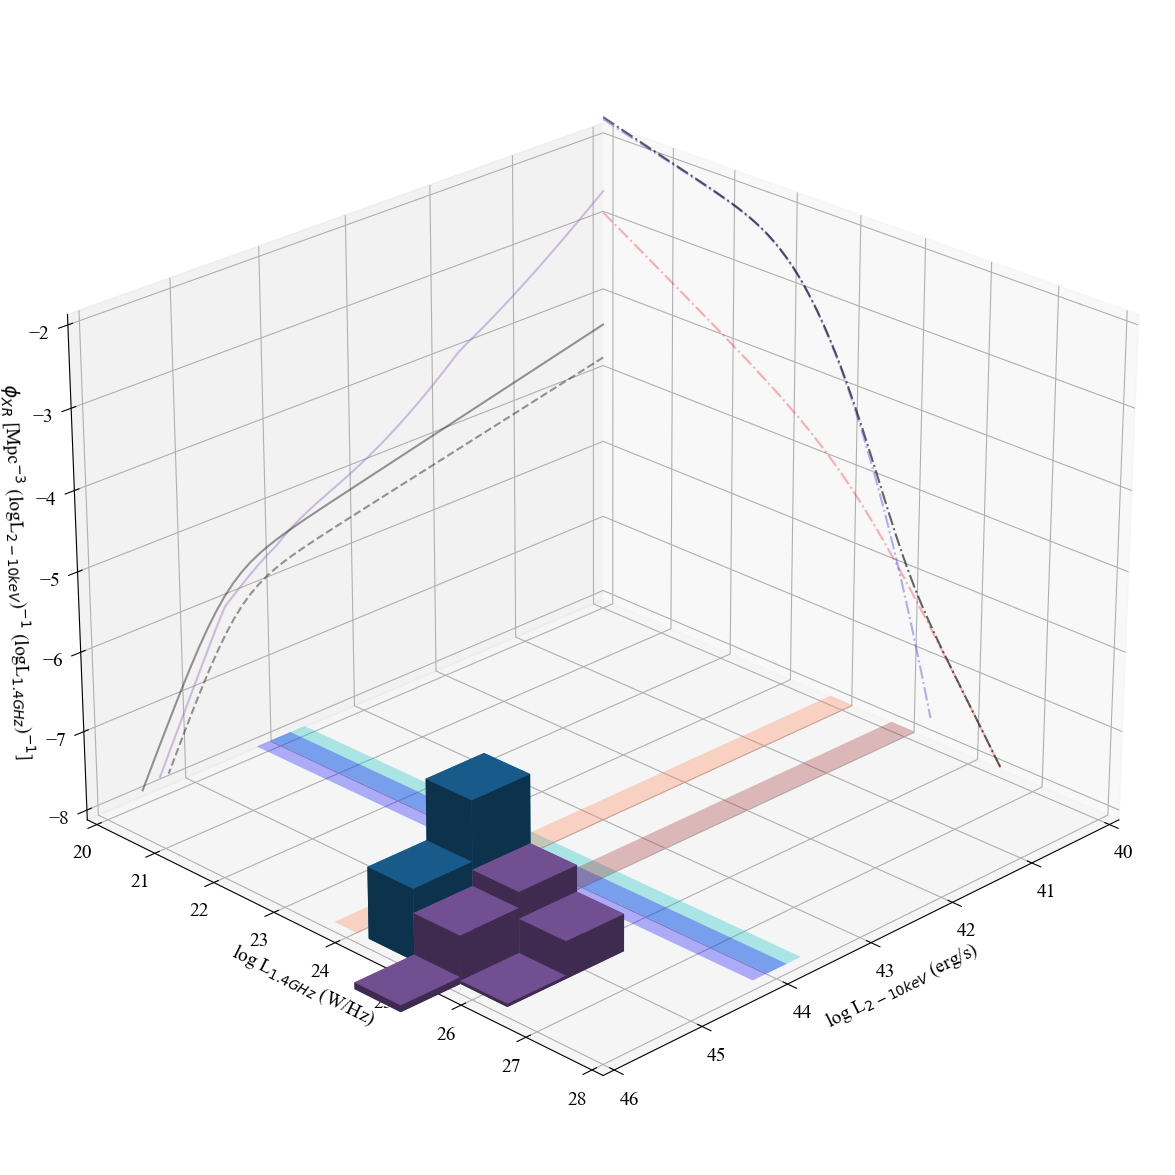

In [38]:
# Load space densities ##############################
stringphi = 'XRLF_phi' + f'{z1}to{z2}' + '.csv' 
#stringphi_upperr = 'XRLF_phi_upperr' + f'{z1}to{z2}' + '.csv' 
#stringphi_lowerr = 'XRLF_phi_lowerr' + f'{z1}to{z2}' + '.csv' 

Phi = np.array(pd.read_csv(stringphi, header=[0], index_col=[0]))
#phi_upp = np.array(pd.read_csv(stringphi_upperr, header=[0], index_col=[0])) 
#phi_low = np.array(pd.read_csv(stringphi_lowerr, header=[0], index_col=[0]))

# Get Luminosity space grid ###########################
nx, nr = 10, 12 # no. of bins

lxmin, lxmax = 40, 46 # min and max of X-ray luminosity range in log space
lrmin, lrmax = 20, 28 # min and max of radio luminosity range in log space

logLx = np.linspace(lxmin,lxmax,nx) # array of evenly spaced log X-ray luminosities
dlogLx = logLx[1]-logLx[0] # log X-ray luminosity bin size 
logLr = np.linspace(lrmin,lrmax,nr) # array of evenly spaced log radio luminosities
dlogLr = logLr[1]-logLr[0] # log radio luminosity bin size 

logLx_2d, logLr_2d = np.meshgrid(logLx, logLr) # 2D array of X-ray and radio luminosity



# Initialise the 3D plot with a grid #####################
fig = plt.figure(figsize = (15,15))
ax = plt.axes(projection='3d')
ax.grid()


##### Plot limits of surveys first, so they don't block the main 3D figure ############
lumxzC1 =  X_flux_to_luminosity(5.95e-16,z1 , 0.5, 7, 2, 10, 1.9)
lumxzC2 =  X_flux_to_luminosity(5.95e-16,z2 , 0.5, 7, 2, 10, 1.9)
lumxzB1 = X_flux_to_luminosity(8.75e-16,z1 , 0.5, 7, 2, 10, 1.9)  
lumxzB2 = X_flux_to_luminosity(8.75e-16,z2 , 0.5, 7, 2, 10, 1.9)  
lumrzB1 = R_flux_to_luminosity(0.32, z1, -0.7, 144, 1400) 
lumrzB2 = R_flux_to_luminosity(0.32, z2, -0.7, 144, 1400) 
lumrzC1 = R_flux_to_luminosity(0.004, z1, -0.7, 3000, 1400)
lumrzC2 = R_flux_to_luminosity(0.004, z2, -0.7, 3000, 1400)

if np.log10(lumxzB1)<40:
    vertsBx = [polygon_under_graph([40, 40, np.log10(lumxzB2), np.log10(lumxzB2)], [20,28, 28, 20])]
else:
    vertsBx = [polygon_under_graph([np.log10(lumxzB1), np.log10(lumxzB1), np.log10(lumxzB2), np.log10(lumxzB2)], [20,28, 28, 20])]
  
if np.log10(lumxzC1)<40:
    vertsCx = [polygon_under_graph([40, 40, np.log10(lumxzC2), np.log10(lumxzC2)], [20,28, 28, 20])]
else:
    vertsCx = [polygon_under_graph([np.log10(lumxzC1), np.log10(lumxzC1), np.log10(lumxzC2), np.log10(lumxzC2)], [20,28, 28, 20])]

if np.log10(lumrzC1)<20:
    vertsCr = [polygon_under_graph([40,46, 46, 40],[20, 20, np.log10(lumrzC2), np.log10(lumrzC2)])]
else:
    vertsCr = [polygon_under_graph([40,46, 46, 40],[np.log10(lumrzC1), np.log10(lumrzC1), np.log10(lumrzC2), np.log10(lumrzC2)])]

if np.log10(lumrzB1)<20:
    vertsBr = [polygon_under_graph([40,46, 46, 40],[20, 20, np.log10(lumrzB2), np.log10(lumrzB2)])]
else:
    vertsBr = [polygon_under_graph([40,46, 46, 40],[np.log10(lumrzB1), np.log10(lumrzB1), np.log10(lumrzB2), np.log10(lumrzB2)])]

polyCx = PolyCollection(vertsCx, facecolors='c', alpha=0.3)#, label="COSMOS X-ray flux limits")
ax.add_collection3d(polyCx, zs=-8, zdir='z')

polyBx = PolyCollection(vertsBx, facecolors='b', alpha=0.3)#, label="Bootes X-ray flux limits")
ax.add_collection3d(polyBx, zs=-8, zdir='z')

polyCr = PolyCollection(vertsCr, facecolors='coral', alpha=0.3)#, label="COSMOS Radio flux limits")
ax.add_collection3d(polyCr, zs=-8, zdir='z')

polyBr = PolyCollection(vertsBr, facecolors='brown', alpha=0.3)#, label="Bootes X-ray flux limits")
ax.add_collection3d(polyBr, zs=-8, zdir='z')



# Create colour array for the 3D plot ############
z_lowlim=np.full(np.shape(logLx_2d), -8)
colours=np.full(np.shape(logLx_2d), 'tab:purple') # X-ray & Radio AGN

loggyLr, phi_mod, phi_SF, phi_AGN = Novak2018_RLF(20, 28, z1, z2)

Rcp=np.where(phi_SF<=phi_AGN)[0][0]

colours[logLx_2d<42] = 'tab:olive' # X-ray SF, Radio AGN
colours[logLr_2d<loggyLr[Rcp]] = 'tab:blue' # # Radio SF, X-ray AGN
colours[(logLr_2d<loggyLr[Rcp]) & (logLx_2d<42)] = 'tab:green' # X-ray & Radio SF



# The 3D plot ###################################
ax.bar3d(x=logLx_2d.flatten(),y=logLr_2d.flatten(),z=z_lowlim.flatten(), dx=dlogLx, dy=dlogLr, dz=(8-abs(np.log10(Phi))).flatten(), color=colours.flatten())
# z is the bottom of the bar and dz is the height from this lower point you want to plot. In logspace so can't pick 0.

ax.set_xlabel("log L$_{2-10keV}$ (erg/s)")
ax.set_ylabel("log L$_{1.4 GHz}$ (W/Hz)")
ax.set_zlabel("$\phi_{XR}$ [Mpc$^{-3}$ (logL$_{2-10keV}$)$^{-1}$ (logL$_{1.4 GHz}$)$^{-1}$]")

ax.set_zlim([-8, -2])
ax.set_ylim([20,28])
ax.set_xlim([40,46])

# Plot the models ##########################
L1=20
L2=28
logLr, phi_mod, phi_SF, phi_AGN = Novak2018_RLF(L1, L2, z1, z2)
ax.plot(loggyLr[np.log10(phi_AGN/dlogLx)>=-8], np.log10(phi_AGN[np.log10(phi_AGN/dlogLx)>-8]/dlogLx), zs=40, zdir='x', c='r',linestyle='-.', alpha=0.3)
ax.plot(loggyLr[np.log10(phi_SF/dlogLx)>=-8], np.log10(phi_SF[np.log10(phi_SF/dlogLx)>=-8]/dlogLx), zs=40, zdir='x',c='b',linestyle='-.', alpha=0.3)
ax.plot(loggyLr[np.log10(phi_mod/dlogLx)>=-8], np.log10(phi_mod[np.log10(phi_mod/dlogLx)>=-8]/dlogLx), zs=40, zdir='x', c='k' ,linestyle='-.',alpha=0.6,label="Novak et al. 2018")#, z={(z1+z2)/2}")


Lx = np.arange(40, 46, 0.1)

z=(z1+z2)/2 # choose the centre of the redshift bin
Uedaphi = ueda_XLF(Lx, z)
AirdHphi = Aird2015_XLF(Lx, z, 2)
AirdSphi = Aird2015_XLF(Lx, z, 1)

ax.plot(Lx[np.log10((Uedaphi).astype(float)/dlogLr)>=-8], np.log10((Uedaphi[np.log10((Uedaphi).astype(float)/dlogLr)>=-8]).astype(float)/dlogLr), zs=20, zdir='y', c='tab:purple', alpha=0.4,   label='Ueda et al. 2014')#, z = {z:.2f}')
ax.plot(Lx[np.log10(AirdHphi/dlogLr)>=-8], np.log10(AirdHphi[np.log10(AirdHphi/dlogLr)>=-8]/dlogLr),zs=20, zdir='y', c='k', alpha=0.4,  label='Aird et al. 2015 (Hard)')#, z = {z:.2f}')
ax.plot(Lx[np.log10(AirdSphi/dlogLr)>=-8], np.log10(AirdSphi[np.log10(AirdSphi/dlogLr)>=-8]/dlogLr), zs=20, zdir='y', c='k', linestyle='--', alpha=0.4,  label='Aird et al. 2015 (Soft)')#, z = {z:.2f}')


# Angle to view the plot at ##################
ax.view_init(elev=25., azim=45)

